This notebook applies an XGBoost classifier to the cleaned and feature-engineered Tunisian electricity dataset.  

Preprocessing is documented here: [data_preprocessing.ipynb](data_preprocessing.ipynb)

# Import function 

In [112]:
!pip install xgboost

In [113]:
# Import modules
from xgboost import XGBClassifier

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from itertools import product

import warnings
warnings.filterwarnings("ignore")

RSEED=42

## Load data

In [114]:
# Read CSV files that have been created from data/created_val.csv, created_test.csv, created_train_res.csv - with low memoryx§
val_df = pd.read_csv('data/created_val.csv', low_memory=False)
test_df = pd.read_csv('data/created_test.csv', low_memory=False)
train_df = pd.read_csv('data/created_train_res.csv', low_memory=False)

print(f"Validation set shape: {val_df.shape}")
print(f"Test set shape: {test_df.shape}")
print(f"Training set shape: {train_df.shape}")

Validation set shape: (27099, 18)
Test set shape: (58069, 17)
Training set shape: (108394, 18)


In [115]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108394 entries, 0 to 108393
Data columns (total 18 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   disrict                              108394 non-null  int64  
 1   client_id                            108394 non-null  object 
 2   client_catg                          108394 non-null  int64  
 3   region                               108394 non-null  int64  
 4   creation_date                        108394 non-null  object 
 5   target                               108394 non-null  float64
 6   1transactions_count                  108377 non-null  float64
 7   gap_days_nanstd                      100554 non-null  float64
 8   consumption_per_month_nanstd         105004 non-null  float64
 9   frac_time_lvl4_nanmax                108377 non-null  float64
 10  consumption_per_month_scaled_nanstd  105004 non-null  float64
 11  active_nanmea

In [116]:
train_df.region.unique()

array([105, 107, 101, 301, 306, 311, 307, 303, 104, 310, 106, 103, 371,
       304, 312, 372, 305, 313, 302, 309, 379, 308, 206, 399, 199])

## Preprocessing 

In [117]:
#convert to data column and extract montn and year as integer
train_df["creation_date"] = pd.to_datetime(train_df["creation_date"])

train_df["creation_month"] = train_df["creation_date"].dt.month
train_df["creation_year"] = train_df["creation_date"].dt.year

train_df = train_df.drop(columns=["creation_date"])

# Apply the same transformations to val_df
val_df["creation_date"] = pd.to_datetime(val_df["creation_date"])
val_df["creation_month"] = val_df["creation_date"].dt.month
val_df["creation_year"] = val_df["creation_date"].dt.year
val_df = val_df.drop(columns=["creation_date"])

In [118]:
#drop client_id column as without predicitive value
train_df = train_df.drop(columns=["client_id"])
val_df = val_df.drop(columns=["client_id"])

In [119]:
#Encoding categorial variable district, region, and
#have rest as numerical columns
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_cols = ["disrict", "client_catg", "region"]

numeric_cols = [col for col in train_df.columns 
                if col not in categorical_cols + ["target"]]

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough"
)

In [120]:
#initial pipeline -  not much pruning
'''
PR-AUC per fold: [0.73033047 0.72672484 0.73238804 0.72403745 0.73275859]
Mean PR-AUC: 0.7292478791417851
Std PR-AUC: 0.00337259408408566
'''


from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

model = Pipeline([
    ("prep", preprocessor),
    ("xgb", XGBClassifier(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.7,
        colsample_bytree=0.7,
        eval_metric="aucpr",
        random_state=42
    ))
])

In [121]:
# Gamma 1 forces only useful split, min_child_weigth
'''
PR-AUC per fold: [0.73235652 0.73794134 0.73428037 0.72405414 0.74465523]
Mean PR-AUC: 0.7346575189904907
Std PR-AUC: 0.006761746843465065
'''
model = Pipeline([
    ("prep", preprocessor),
    ("xgb", XGBClassifier(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=4,
        min_child_weight=5,
        gamma=1,
        subsample=0.7,
        colsample_bytree=0.7,
        reg_alpha=0.5,
        reg_lambda=2,
        eval_metric="aucpr",
        random_state=42
    ))
])

In [133]:
# weight to fraudster (1) is calculate as ration of honest/fraud

n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()

scale_pos_weight = n_neg / n_pos
print(scale_pos_weight)

# gives weight to fraudster on the full dataset
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos

model = Pipeline([
    ("prep", preprocessor),
    ("xgb", XGBClassifier(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=4,
        min_child_weight=5,
        gamma=1,
        subsample=0.7,
        colsample_bytree=0.7,
        reg_alpha=0.5,
        reg_lambda=2,
        eval_metric="auc",
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1
    ))
])

16.907483892284816


In [134]:
# Cross-validation setup, takes into account that data, and folds 
# keep their imbalance
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [136]:
from sklearn.model_selection import cross_val_score

X_train = train_df.drop(columns=["target"])
y_train = train_df["target"]

scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc",   # 👈 changed here
    n_jobs=-1
)

print("ROC-AUC per fold:", scores)
print("Mean ROC-AUC:", scores.mean())
print("Std ROC-AUC:", scores.std())

ROC-AUC per fold: [0.76906067 0.77484685 0.76961496 0.77737582 0.75811462]
Mean ROC-AUC: 0.7698025829003592
Std ROC-AUC: 0.006633137123866551


In [137]:
val_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27099 entries, 0 to 27098
Data columns (total 18 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   disrict                              27099 non-null  int64  
 1   client_catg                          27099 non-null  int64  
 2   region                               27099 non-null  int64  
 3   target                               27099 non-null  float64
 4   1transactions_count                  27094 non-null  float64
 5   gap_days_nanstd                      25138 non-null  float64
 6   consumption_per_month_nanstd         26256 non-null  float64
 7   frac_time_lvl4_nanmax                27094 non-null  float64
 8   consumption_per_month_scaled_nanstd  26256 non-null  float64
 9   active_nanmean                       27094 non-null  float64
 10  counter_statue_nanstd                26256 non-null  float64
 11  reading_remarque_nanstd     

In [138]:
# 1. define X / y
X_train = train_df.drop(columns=["target"])
y_train = train_df["target"]

X_val = val_df.drop(columns=["target"])
y_val = val_df["target"]

# 2. fit full pipeline on training data
model.fit(X_train, y_train)

# 3. predict probabilities on validation data
y_prob = model.predict_proba(X_val)[:, 1]

# 4. ROC-AUC on validation set
from sklearn.metrics import roc_auc_score

roc_auc_val = roc_auc_score(y_val, y_prob)

print("Validation ROC-AUC:", roc_auc_val)

Validation ROC-AUC: 0.7753642072000193


In [140]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

model = Pipeline([
    ("prep", preprocessor),
    ("rf", RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

param_grid = {
    "rf__n_estimators": [200, 500],
    "rf__max_depth": [10, 20],
    "rf__min_samples_split": [2, 10],
    "rf__min_samples_leaf": [1, 5],
    "rf__max_features": ["sqrt"]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=2,
    refit=True
)

grid.fit(X_train, y_train)

print("Best ROC-AUC:", grid.best_score_)
print("Best params:")
print(grid.best_params_)

best_model = grid.best_estimator_

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END rf__max_depth=10, rf__max_features=sqrt, rf__min_samples_leaf=1, rf__min_samples_split=2, rf__n_estimators=200; total time=  26.8s
[CV] END rf__max_depth=10, rf__max_features=sqrt, rf__min_samples_leaf=1, rf__min_samples_split=2, rf__n_estimators=200; total time=  26.9s
[CV] END rf__max_depth=10, rf__max_features=sqrt, rf__min_samples_leaf=1, rf__min_samples_split=2, rf__n_estimators=200; total time=  26.8s
[CV] END rf__max_depth=10, rf__max_features=sqrt, rf__min_samples_leaf=1, rf__min_samples_split=2, rf__n_estimators=200; total time=  26.9s
[CV] END rf__max_depth=10, rf__max_features=sqrt, rf__min_samples_leaf=1, rf__min_samples_split=2, rf__n_estimators=200; total time=  27.4s
[CV] END rf__max_depth=10, rf__max_features=sqrt, rf__min_samples_leaf=1, rf__min_samples_split=10, rf__n_estimators=200; total time=  26.5s
[CV] END rf__max_depth=10, rf__max_features=sqrt, rf__min_samples_leaf=1, rf__min_samples_split=10

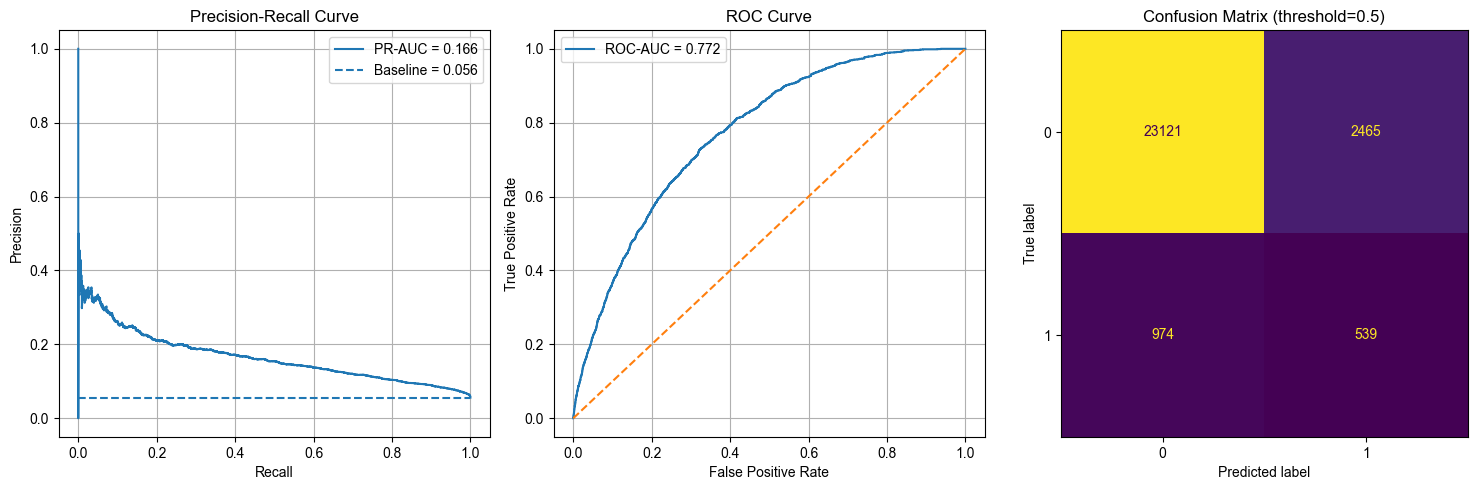

In [152]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    roc_curve,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# -------------------------
# make sure probabilities come from VALIDATION set
# -------------------------
y_prob_val = best_model.predict_proba(X_val)[:, 1]

# ---- choose threshold ----
threshold = 0.5

# ---- predictions ----
y_pred = (y_prob_val >= threshold).astype(int)

# ---- PR curve ----
precision, recall, _ = precision_recall_curve(y_val, y_prob_val)
pr_auc = average_precision_score(y_val, y_prob_val)

# ---- ROC curve ----
fpr, tpr, _ = roc_curve(y_val, y_prob_val)
roc_auc = roc_auc_score(y_val, y_prob_val)

# ---- confusion matrix ----
cm = confusion_matrix(y_val, y_pred)

# ---- plot ----
plt.figure(figsize=(15,5))

# PR-AUC
plt.subplot(1,3,1)
plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.3f}")
baseline = y_val.mean()
plt.hlines(baseline, 0, 1, linestyles="dashed", label=f"Baseline = {baseline:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid()

# ROC-AUC
plt.subplot(1,3,2)
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1], linestyle="dashed")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()

# Confusion Matrix
plt.subplot(1,3,3)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=plt.gca(), colorbar=False)
plt.title(f"Confusion Matrix (threshold={threshold})")

plt.tight_layout()
plt.show()

## Presentation images

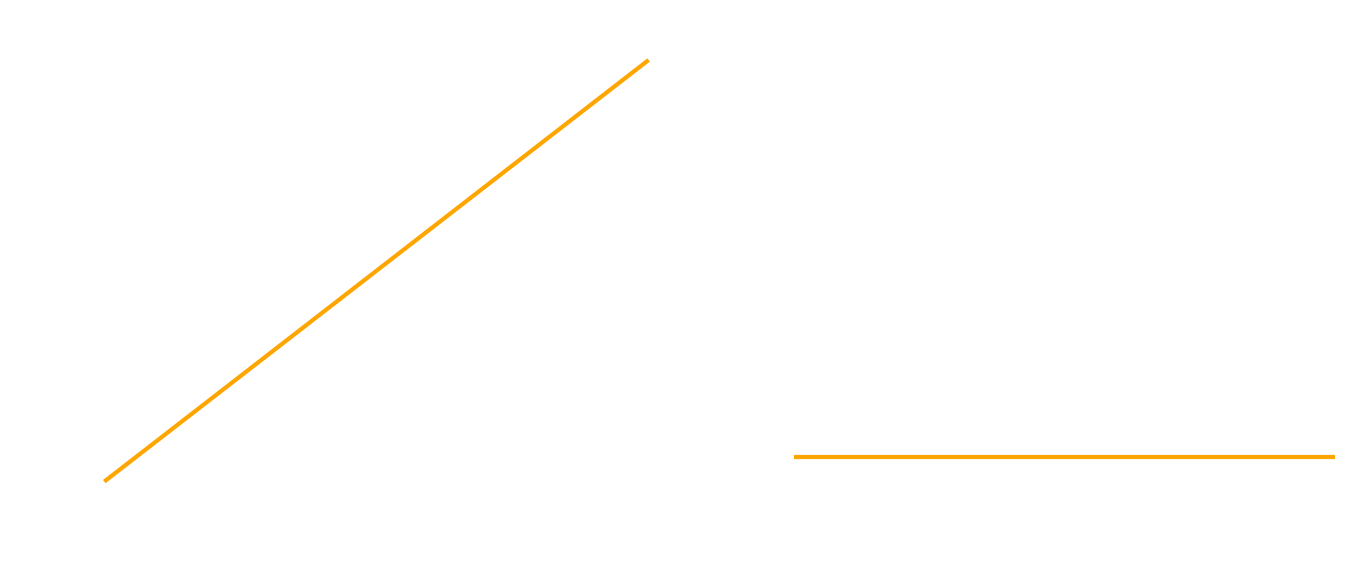

In [156]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve

# -------------------------
# GLOBAL STYLE
# -------------------------
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 16,              # base
    "axes.titlesize": 22,
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14
})

# -------------------------
# DATA
# -------------------------
y_prob_val = best_model.predict_proba(X_val)[:, 1]

fpr, tpr, _ = roc_curve(y_val, y_prob_val)
precision, recall, _ = precision_recall_curve(y_val, y_prob_val)

# -------------------------
# PLOT
# -------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_alpha(0)  # transparent background

# ROC
axes[0].plot(fpr, tpr, color="white", linewidth=5)
axes[0].plot([0, 1], [0, 1], color="orange", linewidth=3)

axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")

# PR
axes[1].plot(recall, precision, color="white", linewidth=5)

baseline = y_val.mean()
axes[1].hlines(baseline, 0, 1, colors="orange", linewidth=3)

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")

# -------------------------
# CLEAN + THICK AXES
# -------------------------
for ax in axes:
    ax.set_facecolor("none")

    # remove clutter
    ax.grid(False)
    if ax.get_legend() is not None:
        ax.legend().remove()

    # remove top/right
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # THICK AXES
    ax.spines["left"].set_linewidth(3)
    ax.spines["bottom"].set_linewidth(3)
    ax.spines["left"].set_color("white")
    ax.spines["bottom"].set_color("white")

    # THICK TICKS
    ax.tick_params(axis='both', colors='white', width=3, length=6)

    # TEXT COLOR
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")
    ax.title.set_color("white")

# -------------------------
# SAVE (important: BEFORE show)
# -------------------------
import os
os.makedirs("images_for_presi", exist_ok=True)

plt.tight_layout()
plt.savefig(
    "images_for_presi/roc_pr_transparent.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

plt.show()

In [155]:
plt.savefig("images_for_presi/roc_pr_transparent.png", dpi=300, bbox_inches="tight", transparent=True)

<Figure size 640x480 with 0 Axes>

In [128]:
X = train_df.drop(columns=["target"])
y = train_df["target"]

In [147]:
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score

# -------------------------
# 1. LOAD DATA
# -------------------------
train_df = pd.read_csv("data/created_train_res.csv")
val_df   = pd.read_csv("data/created_val.csv")
test_df  = pd.read_csv("data/created_test.csv")
submission = pd.read_csv("data/SampleSubmission.csv")

# -------------------------
# 2. CONVERT creation_date IN ALL DATAFRAMES
# -------------------------
for df in [train_df, val_df, test_df]:
    if "creation_date" in df.columns:
        df["creation_date"] = pd.to_datetime(df["creation_date"], dayfirst=True, errors="coerce")
        df["creation_month"] = df["creation_date"].dt.month
        df["creation_year"] = df["creation_date"].dt.year
        df.drop(columns=["creation_date"], inplace=True)

# -------------------------
# 3. DEFINE FEATURES
# -------------------------
drop_cols = ["target", "client_id"]
drop_cols = [c for c in drop_cols if c in train_df.columns]

X_train = train_df.drop(columns=drop_cols)
y_train = train_df["target"]

X_test = test_df[X_train.columns]

# -------------------------
# 4. TRAIN MODEL
# -------------------------
best_model.fit(X_train, y_train)

# -------------------------
# 5. VALIDATION
# -------------------------
if "target" in val_df.columns:
    X_val = val_df[X_train.columns]
    y_val = val_df["target"]

    y_prob_val = best_model.predict_proba(X_val)[:, 1]

    print("Validation ROC-AUC:", roc_auc_score(y_val, y_prob_val))
    print("Validation PR-AUC:", average_precision_score(y_val, y_prob_val))

# -------------------------
# 6. PREDICT TEST
# -------------------------
y_prob = best_model.predict_proba(X_test)[:, 1]
print("Prediction range:", y_prob.min(), y_prob.max())

# -------------------------
# 7. SUBMISSION
# -------------------------
submission["target"] = y_prob
submission.to_csv("submission.csv", index=False)

print("submission.csv saved")

Validation ROC-AUC: 0.7717201590488934
Validation PR-AUC: 0.16588579981788015
Prediction range: 0.0 0.8720122569284916
submission.csv saved
